# Лабораторная работа: обучение многообразий

# PCA

В этом блоке вам предстоит выполнить задания, касающиеся метода главных компонент (`PCA`).

## Теоретическая часть

Пусть на вход подаются центрированные данные
$$
x_i = \begin{pmatrix}
x_{i1} \\ x_{i2} \\ \vdots \\ x_{ip}
\end{pmatrix} \in \mathbb R^{p \times 1}, \quad i \in \{1, \ldots, n\}, \quad \sum\limits_{i = 1}^n x_i = 0.
$$
Пусть также $X$ — матрица размера $n \times p$ — матрица объекты-признаки (внимание: объекты расположены в матрице $X$ по строкам), $W$ – матрица размера $p \times l$ из ортонормированных базисных векторов (их координаты записаны по столбцам) линейного подпространства $\mathbb R^l$ пространства $\mathbb R^p$, в которое мы хотим «вложить» исходные объекты, $Z$ — матрица размера $n \times l$ — матрица координат старых объектов в новом базисе. Мы определили функцию потерь ($l_2$-потери) следующим образом:

$$
L(W) = \|X^T - WZ^T\|^2_F = \sum\limits_{i = 1}^n \|x_i - Wz_i\|^2.
$$

На лекции мы обсудили построение первой главной компоненты, минимизируя выражение

$$
L(W) = \sum\limits_{i = 1}^n\|x_i - w_1z_{i1}\|^2.
$$

При условии, что $w_1^Tw_1 = 1$, мы получили, что

$$
z_{i1} = x_i^Tw_1,
$$

то есть что новая координата есть проекция на $w_1$, и что $w_1$ — собственный вектор выборочной ковариационной матрицы

$$
\Sigma = \frac{1}{n}X^TX,
$$

отвечающей наибольшему собственному значению.



## Задача 1

Вам требуется построить первые две главные компоненты, объяснить сособ их получения, а также их геометрический и статистический смыслы. Для этого:

1.   Составьте минимизируемый функционал.
2.   Докажите, что новые координаты (счеты) — это проекции исходных данных на соотвествующие векторы $w_1$, $w_2$.
3. Докажите, что $w_1$, $w_2$ — это собственные векторы выборочной ковариационной матрицы, отвечающие двум наибольшим собственным значениям, по убыванию, соответственно.
4. Покажите, что статистический смысл упомянутых выше собственных чисел — значение выборочных дисперсий соответствующих (новых) координат.

**Решение:** 
# Построение первых двух главных компонент (PCA). Минимизация, проекции собственные векторы и смысл собственных чисел
Пусть у нас есть выборка $x_1$, ... , $x_n$ $\in R^p$. Центрирую данные: $$\bar{x}=\frac{1}{n} \sum_{j=1}^{n} x_j\quad \tilde{x_j} := x_j - \bar{x}$$
Собираю матрицу центровок X $\in R^{n \times p}$ c строками $\tilde{x}_j^T$. Обозначу выборную ковариационную матрицу $$S = \frac{1}{n}X_T\times X \in R^{p \times p}$$
(можно взять $\frac{1}{n-1}$ но это не окажет особого влияния, так как это просто масштабирование данных)
Моя цель - это выразить два ветора $w_1,w_2 \in R^p$. Эти два вектора таковы, что $\|w_i\| = 1$ и $w_1 \perp w_2$.

# Считаю каждый вектор через минимизацию среднеквадратичной ошибки
Апроксимация каждого вектора $\tilde{x_j}$:
$$\bar{\tilde{x}_j} = (w_1^T\tilde{x}_j)w_1+(w_2^T\tilde{x}_j)w_2$$
тогда какая-то функция ошибки составит:
$$F(w_1,w_2) = \sum_{j=1}^{n}\|\tilde{x}_j-\bar{\tilde{x}_j}\|^2$$

# Новые координаты — проекции данных на \(w_1\) и \(w_2\)

Определим новые координаты (скоры):
$$
z_{j1}=w_1^\top\tilde x_j,\qquad 
z_{j2}=w_2^\top\tilde x_j.
$$

# В матричной форме:
$$
Z = X W,\qquad W=[w_1\; w_2] \in \mathbb R^{p\times 2}.
$$

То есть новые координаты — **проекции данных на найденные направления**.

То есть оптимальное направление — **собственный вектор ковариационной матрицы**.

Максимум достигается на собственном векторе, соответствующем **наибольшему собственному значению** $(\lambda_1)$.

Вторая компонента находится аналогично, но в подпространстве, ортогональном $(w_1)$.  
Получаем:  
$$
w_1, w_2 \text{ — собственные векторы } S,\quad 
\lambda_1 \ge \lambda_2.
$$

Рассмотрим собственный вектор $(w)$ с собственным значением $(\lambda)$:

$$
\operatorname{Var}(w^\top \tilde x) = w^\top S w.
$$

Но если $(S w = \lambda w), \text{и} (\|w\|=1)$, то:
$$
w^\top S w = w^\top (\lambda w) = \lambda.
$$

Следовательно:

$$
\operatorname{Var}(z_1) = \lambda_1,\qquad 
\operatorname{Var}(z_2) = \lambda_2.
$$

То есть **собственные числа ковариационной матрицы — это дисперсии главных компонент**.
# Итог

1. Функционал: либо минимизация ошибки реконструкции  
   $$
   F(w_1,w_2),
   $$
   либо максимизация суммарной дисперсии проекций.

2. Новые координаты — проекции на $(w_1)$ и $(w_2)$.

3. w_1,w_2 — собственные векторы ковариационной матрицы S, соответствующие двум наибольшим собственным значениям.

4. Собственные числа $\lambda_1,\lambda_2$ — дисперсии новых координат (главных компонент).

## Задача 2

Предыдущий подход хорошо работает в случае, когда $n$ сильно больше $p$. В противном случае разумнее рассматривать тоже симметричную матрицу $XX^T$. Ваша задача, взяв конкретную матрицу $X$ (скажем, размера $3 \times 3$, но можно и в общем виде), показать, что

1.   Существует ортогональная матрица $U$, что

$$
U^TXX^TU = \Lambda,
$$

где последняя матрица — диагональная.

2.   Верно равенство

$$
XX^TU = U \Lambda,
$$

а значит и равенство

$$
X^TXX^TU = X^TU \Lambda,
$$

откуда

$$
(X^TX)(X^TU) = X^TU \Lambda
$$

и $X^TU$ — матрица из собственных векторов для $X^TX$.

3. Показать, что столбцы матрицы $X^TU$ ортогональны, но не ортонормированы.

4. Найти нормы столбцов $X^TU$, привести преобразование к ортогональному. Получить аналог `PCA`.

5. Показать численно (на конкретной матрице) с использованием, например, `numpy`.

**Решение:** ###

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

def center_data(X: np.array, Y: np.array):
    x_list = X.tolist()
    y_list = Y.tolist()

    n_samples = len(x_list)
    n_features = len(x_list[0])

    means = list()
    for j in range(n_features):
        s = 0
        for i in range(len(y_list)):
            s += y_list[i][j]
        means.append(s / len(y_list))

    x_centered = list()
    for i in range(n_samples):
        row = list()
        for j in range(n_features):
            row.append(x_list[i][j] - means[j])
        x_centered.append(row)

    return np.array(x_centered)


def get_cov_matrix(X: np.array) -> np.array:
    x_list = X.tolist()
    n_samples = len(x_list)
    n_features = len(x_list[0])

    cov_matrix = list()
    trans = [[0 for _ in range(n_samples)] for _ in range(n_features)]

    for i in range(n_samples):
        for j in range(n_features):
            trans[j][i] = x_list[i][j]

    for i in range(n_features):
        sp = list()
        for j in range(n_features):
            s = 0
            for k in range(n_samples):
                s += trans[i][k] * x_list[k][j]
            sp.append(s / n_samples)
        cov_matrix.append(sp)

    return np.array(cov_matrix)


def dot(A, B):
    result = [[0.0 for _ in range(len(B[0]))] for _ in range(len(A))]
    for i in range(len(A)):
        for j in range(len(B[0])):
            for k in range(len(B)):
                result[i][j] += A[i][k] * B[k][j]
    return result


def transpose(M):
    return [[M[j][i] for j in range(len(M))] for i in range(len(M[0]))]


def norm(v):
    return sum(x * x for x in v) ** 0.5


def power_iteration(A, num_iter=1000, tol=1e-10):
    n = len(A)
    v = [1.0] * n
    for _ in range(num_iter):
        Av = [row[0] for row in dot(A, [[x] for x in v])]
        a = sum(v[i] * Av[i] for i in range(n)) / sum(v[i] * v[i] for i in range(n))
        norm_Av = norm(Av)
        if norm_Av == 0:
            return 0, [0.0] * n
        v_next = [x / norm(Av) for x in Av]
        if all(abs(v_next[i] - v[i]) < tol for i in range(n)):
            break
        v = v_next
    return a, v


def deflate(A, a, v):
    n = len(A)
    for i in range(n):
        for j in range(n):
            A[i][j] -= a * v[i] * v[j]
    return A


def get_components(cov_matrix):
    A = [row[:] for row in cov_matrix]
    n = len(A)
    eigenvalues = list()
    eigenvectors = list()

    for _ in range(n):
        a, v = power_iteration(A)
        eigenvalues.append(a)
        eigenvectors.append(v)
        A = deflate(A, a, v)

    eig_pairs = sorted(zip(eigenvalues, eigenvectors), key=lambda x: -x[0])
    sorted_vecs = [vec for _, vec in eig_pairs]

    components = transpose(sorted_vecs)
    return np.array(components)


def get_new_coords(centered_data, components, n_components):
    centered_data = centered_data.tolist()
    n_samples = len(centered_data)
    n_features = len(centered_data[0])

    W = [components[i][:n_components] for i in range(n_features)]

    Z = list()
    for i in range(n_samples):
        row = list()
        for j in range(n_components):
            s = 0
            for k in range(n_features):
                s += centered_data[i][k] * W[k][j]
            row.append(s)
        Z.append(row)
    return np.array(Z)


X = np.array([
    [3., 1., 1.],
    [-1., 3., 1.],
    [3., 3., 1.]
])


XXT = X @ X.T
print("XX^T =\n", XXT)


U = get_components(XXT)
λ = np.array([norm(X.T @ U[:, i])**2 for i in range(3)])
print("\nEigenvalues of XX^T: ", λ)
print("\nMatrix U (eigenvectors of XX^T):\n", U)


XTU = X.T @ U
print("\nX^T U =\n", XTU)


G = XTU.T @ XTU
print("\nGram matrix (X^T U)^T (X^T U) =\n", G)


#Нормы столбцов = sqrt(λ)
norms = np.array([norm(XTU[:, i]) for i in range(3)])
print("\nColumn norms of X^T U:", norms)
print("sqrt(lambda):", np.sqrt(λ))


#Строю матрицу V = X^T U Λ^{-1/2}
Λ_inv_sqrt = np.diag(1/np.sqrt(λ))
V = XTU @ Λ_inv_sqrt
print("\nV (orthonormal) =\n", V)
print("V^T V =\n", V.T @ V)


#Проверка SVD: X ≈ U Σ V^T
Σ = np.diag(np.sqrt(λ))
X_rec = U @ Σ @ V.T
print("\nReconstructed X =\n", X_rec)
print("Reconstruction error =", np.linalg.norm(X - X_rec))

XX^T =
 [[11.  1. 13.]
 [ 1. 11.  7.]
 [13.  7. 19.]]

Eigenvalues of XX^T:  [30.61634256 10.17828022  0.20537722]

Matrix U (eigenvectors of XX^T):
 [[ 0.53645584 -0.45258784  0.71230568]
 [ 0.30776032  0.89082594  0.33423454]
 [ 0.78581086 -0.03991735 -0.61717736]]

X^T U =
 [[ 3.6590398  -2.36834151 -0.04884957]
 [ 3.8171694   2.10013793 -0.13652277]
 [ 1.63002703  0.39832075  0.42936286]]

Gram matrix (X^T U)^T (X^T U) =
 [[ 3.06163426e+01 -5.44286956e-09  4.61560613e-12]
 [-5.44286956e-09  1.01782802e+01 -3.66844482e-08]
 [ 4.61560613e-12 -3.66844482e-08  2.05377216e-01]]

Column norms of X^T U: [5.53320364 3.19034171 0.45318563]
sqrt(lambda): [5.53320364 3.19034171 0.45318563]

V (orthonormal) =
 [[ 0.66128775 -0.74234729 -0.10779153]
 [ 0.68986606  0.65827993 -0.30125132]
 [ 0.2945901   0.12485206  0.94743265]]
V^T V =
 [[ 1.00000000e+00 -3.08328955e-10  1.84066065e-12]
 [-3.08328955e-10  1.00000000e+00 -2.53728153e-08]
 [ 1.84066065e-12 -2.53728153e-08  1.00000000e+00]]

Recons

## Практическая часть

Рассмотрим применение `PCA` в разрезе работы с зашумленными данными. Наша цель — выяснить, можно ли при помощи метода каким-то образом избавляться от шума в данных. Прежде чем двигаться дальше к конкретике, предположите, осуществимо ли это и, если ответ положительный, попробуйте предложить конкретный способ (с обоснованием).

Предположим следующую ситуацию: решается задача классификации, есть некоторый тренировочный набор данных (эталонный, возможно синтетический), на котором обучается модель классификации. Данные же для предсказания поступают в некотором "зашумленном" виде: например, барахлит датчик/некачественная аппаратура/проблемы канала передачи данных, etc. Для повышения качества классификации разумно попробовать избавиться от шума в данных. Попробуем смоделировать такую ситуацию.

**Примечание:** в качества классификатора будет выступать [логистическая регрессия](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html). В рамках этой работы не будем вникать в суть самого метода, но будем использовать его как некоторый абстрактный классификатор, который поможет нам численно оценить то, насколько хорошо мы избавились от шума.

Будем работать с `FashionMNIST`

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

(np.float64(-0.5), np.float64(419.5), np.float64(279.5), np.float64(-0.5))

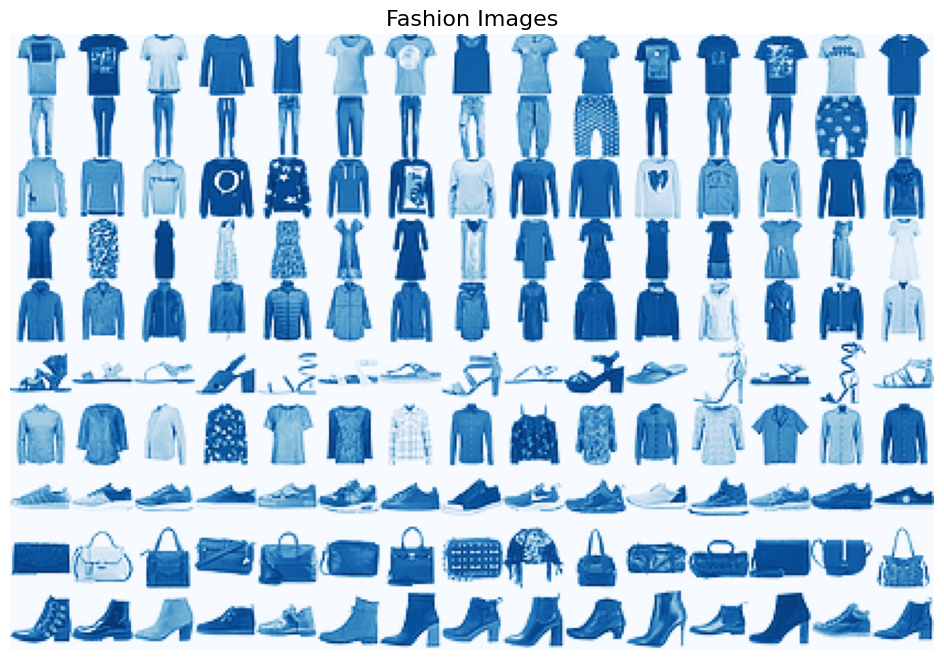

In [7]:
classes = sorted(np.unique(train_labels).astype(int))
h = w = 28
n_samples = 15

fig, ax = plt.subplots(figsize=(18, 8))
fashion_sample = np.empty(shape=(h * len(classes),
                                 w * n_samples))

for row, label in enumerate(classes):
    label_idx = np.argwhere(train_labels == label).squeeze()
    sample_indices = np.random.choice(label_idx, size=n_samples, replace=False)
    i = row * h
    for col, sample_idx in enumerate(sample_indices):
        j = col * w
        sample = train_images[sample_idx].reshape(h, w)
        fashion_sample[i:i+h, j:j + w] = sample

ax.imshow(fashion_sample, cmap='Blues')
ax.set_title('Fashion Images', fontsize=16)
plt.axis('off')

Набор данных содержит изображения различных предметов одежды: футболки, штаны, кофты, платья, обувь различного вида, etc. Всего $10$ классов. Для меньших временных затрат будем использовать только данные из тестовой части исходного набора данных (всего $10$ тысяч объектов).

In [8]:
X = test_images.reshape(len(test_images), -1)
y = test_labels

При помощи `train_test_split` разбейте набор данных на тренировочную и тестовую части в соотношении `80:20`. Используйте стратификацию по колонке отклика.

**Примечание:** здесь и далее для воспроизводимости результатов и корректного сравнения результатов экспериментов имеет смысл фиксировать `random_state`.

In [9]:
from sklearn.model_selection import train_test_split


X_train,X_test,y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Обучите модель `LogisticRegression` со следующими параметрами: `max_iter=2000, tol=0.001` на тренировочных данных. При помощи `f1_score` с параметром `average='weighted'` оцените модель на тестовых данных.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,classification_report,accuracy_score

model = LogisticRegression(max_iter=2000, tol=0.001)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average="weighted")
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_micro = f1_score(y_test, y_pred, average="micro")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.7445
F1 Score (weighted): 0.7444
F1 Score (macro): 0.7444
F1 Score (micro): 0.7445
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.68      0.68       200
           1       0.92      0.96      0.94       200
           2       0.57      0.65      0.60       200
           3       0.76      0.68      0.71       200
           4       0.62      0.66      0.64       200
           5       0.89      0.73      0.81       200
           6       0.46      0.43      0.44       200
           7       0.84      0.89      0.87       200
           8       0.90      0.86      0.88       200
           9       0.85      0.91      0.87       200

    accuracy                           0.74      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.75      0.74      0.74      2000



**Вопрос:** как работает `f1_score` и что показывает данная метрика? Опишите ее плюсы и минусы. Что означает параметр `average='weighted'`? Какие еще бывают параметры, зачем и когда они используются?

**Ваш ответ:**
Это метрика, которая представляет собой гармоническое среднее (harmonic mean) двух ключевых метрик классификации: Точности (Precision) и Полноты (Recall). Она используется для оценки качества работы модели на задачах классификации, особенно когда важен баланс между Precision и Recall, или когда классы несбалансированы.
$$F1 = 2 \times \frac{precision \times recall}{precision+recall}$$


Добавьте к тестовым данным шум при помощи `np.random.normal(X_test, scale)`, где `scale` $\in \{50,100,150,200\}$. Визуально оцените результаты.

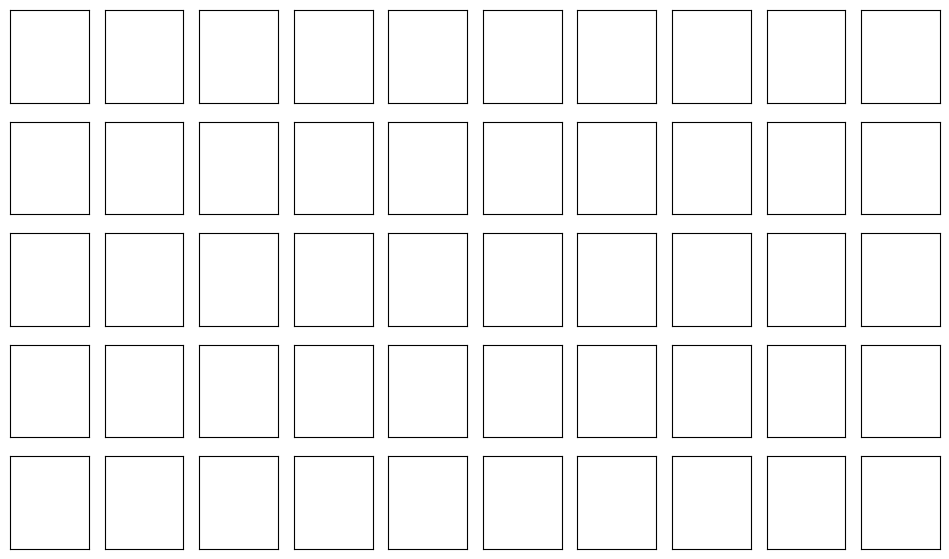

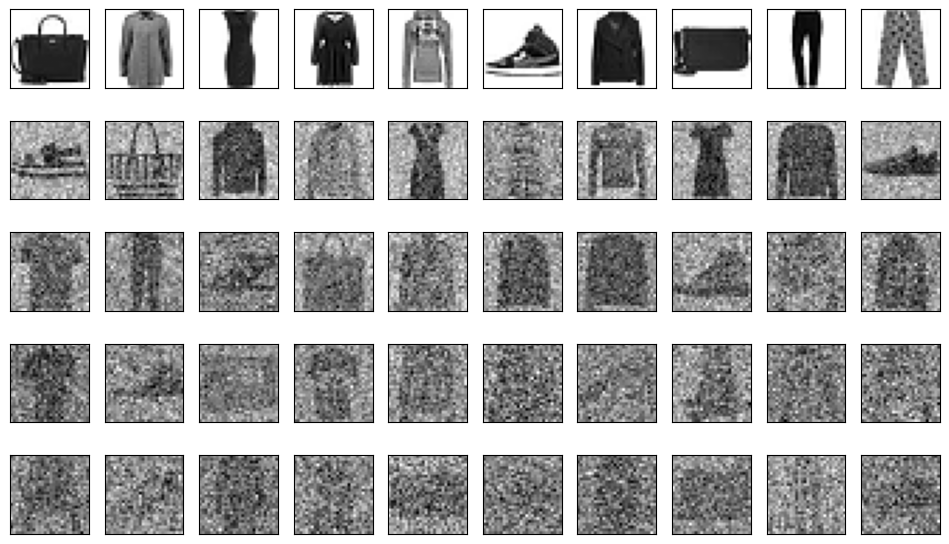

In [11]:
scales = [0, 50, 100, 150, 200]
X_test_noisy = []
y_test_noisy = list()

for scale in scales:
    if scale == 0:
        noisy = X_test
    else:
        noisy = np.random.normal(X_test, scale)
    # Выбор 10 случайных индексов для каждого масштаба
    indices = np.random.choice(len(X_test), 10, replace=False)
    for idx in indices:
        X_test_noisy.append(noisy[idx])
        y_test_noisy.append(y_test[idx])

X_test_noisy = np.array(X_test_noisy)
y_test_noisy = np.array(y_test_noisy)

# Визуальная оценка результатов
fig, axes = plt.subplots(
    5, 10, figsize=(12, 7), subplot_kw={"xticks": [], "yticks": []}
)

fig, axes = plt.subplots(5, 10, figsize=(12, 7), subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test_noisy[i].reshape(28, 28), cmap=plt.cm.gray_r)

**Ваши выводы:**
При добавлении шума происходит следующее: Так как он добавляется в соответствии с нормальным распределением, следовательно по мере повышения его значения функция N(0,scale) начинает выдовать значения выходящие за границы [-255,255] с большей вероятностью, следовательно, какие-то значения вообще становятся бессмысленными, что приводит тому, что изображения становятся практически не распознаваемыми.

Произведите предсказания для зашумленных тестовых данных. Оцените результат при помощи `f1_score` с параметром `average='weighted'`.

In [12]:
y_pred_noisy = model.predict(X_test_noisy)

f1_noisy_weighted = f1_score(y_test_noisy, y_pred_noisy, average="weighted")
print(f"F1 Score (weighted) on noisy test data: {f1_noisy_weighted:.4f}")

F1 Score (weighted) on noisy test data: 0.4397


**Ваши выводы:**
Так как большинство признаков становятся бесссмысленными вследствие добавления шума, следовательно и точность теряется, так как я теряю очень большое количество признаков, именно с эти и связана такая точность модели

Попробуем избавиться от шума при помощи метода главных компонент.

Обучите модель `PCA(explained_variance)` на зашумленных тестовых данных, где `explained_variance` $\in [0.1, 0.9]$ с шагом $0.1$. Уменьшите размерность зашумленных тестовых данных, а затем при помощи `.inverse_transform()` "восстановите" данные до приближенных исходных.

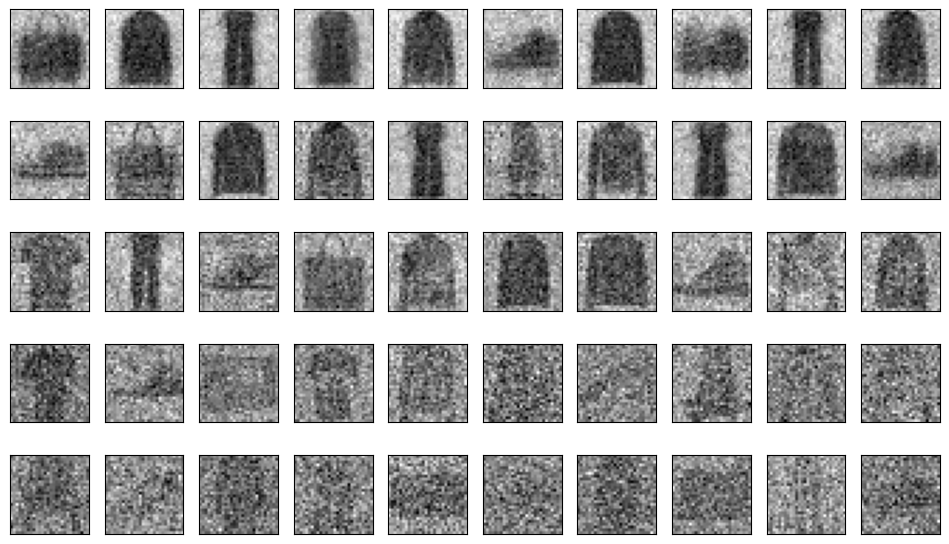

In [13]:
from sklearn.decomposition import PCA


explained_variances = np.arange(0.1, 1.0, 0.1)
for explained_variance in explained_variances:
    pca = PCA(n_components=explained_variance)
    pca.fit(X_test_noisy)
    X_reduced = pca.transform(X_test_noisy)
    restored_X_test_noisy = pca.inverse_transform(X_reduced)

fig, axes = plt.subplots(5, 10, figsize=(12, 7), subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(restored_X_test_noisy[i].reshape(28, 28), cmap=plt.cm.gray_r)

**Ваши выводы:** 
Данные, которые разжимаются обратно довольно неплохо соответсвуют исходным при довольно большом сохранении количества передаваемой информации (компонент), то етсь можно сделать вывод, что PCA довольно точно сжимает информация и приводит ее в исходный вид.

Произведите предсказания для очищенных от шума данных. Оцените результат при помощи `f1_score` с параметром `average='weighted'`.

In [14]:
y_pred_restored = model.predict(restored_X_test_noisy)
f1_restored_weighted = f1_score(y_test_noisy, y_pred_restored, average="weighted")
print(f"F1 Score (weighted) on restored test data: {f1_restored_weighted:.4f}")

F1 Score (weighted) on restored test data: 0.3946


В качестве результата **НАГЛЯДНО** представьте получаемые значения `f1_score` в зависимости от используемого уровня шума и доли объясненной дисперции (таблицы, графики, диаграммы). Сделайте выводы.

**Ваши выводы:**
точность падает примерно на 20% от тех значений на которых была обучена модель не знаю можно ли считать эту потерю критичной, но как мне кажется модель весьма успешно восстанавливает данные, хотя потеря в 40% является существенной

# t-SNE

В этом блоке вам предстоит выполнить задания, касающиеся `t-SNE`.

## Теоретическая часть

Напомним, что расстояние Кульбака--Лейблера между двумя распределенями $P = \{p_1, \ldots, p_n\}$, $Q = \{q_1, \ldots, q_n\}$ вычисляется как
$$
\mathbb{KL}(P|Q) = \sum\limits_{i=1}^np_i \log \frac{p_i}{q_i}.
$$

Пусть перплексия равна $k$. Положите $p_{i|j} = 1/k$ для $k$ ближайших соседей точки $j$ за исключением $j$, $p_{j|j} = 0$, как и остальные вероятности. Положите
$$
p_{ij} = \frac{p_{i|j} + p_{j|i}}{2n}.
$$

## Задача 1

Вычислите градиент $\mathbb{KL}$ в случае использования `SNE` и `t-SNE`.

**Ваш ответ:**
# Различия в математическом аппарате SNE и t-SNE

Алгоритмы SNE и t-SNE используются для **нелинейного понижения размерности** и визуализации данных. Их ключевое различие заключается в том, как они моделируют **вероятность** $q_{ij}$ (сходство точек $y_i$ и $y_j$ в низкоразмерном пространстве) и, соответственно, в виде **градиента** функции потерь (дивергенции Кульбака-Лейблера $C$).

# 1. SNE (Stochastic Neighbor Embedding)

SNE использует **Гауссово ядро** (нормальное распределение) для моделирования сходства в низкоразмерном пространстве.

**Моделирование сходства (Вероятность $q_{ij}$):**
    $$q_{ij} \propto \exp(-\|y_i-y_j\|^2)$$
    Это означает, что **расстояния в низкоразмерном пространстве** штрафуются **экспоненциально** (легкие хвосты).

**Градиент расстояния KL ($\partial C / \partial y_i$):**
    $$
    \frac{\partial C}{\partial y_i} = 4\sum_j (p_{ij}-q_{ij})(y_i-y_j)
    $$
# 2. t-SNE (t-distributed Stochastic Neighbor Embedding)

t-SNE использует **t-распределение Стьюдента со степенью свободы $df=1$** (функцию Коши) для моделирования сходства в низкоразмерном пространстве.

* **Моделирование сходства (Вероятность $q_{ij}$):**
    $$q_{ij} \propto \frac{1}{1+\|y_i-y_j\|^2}$$
    Это создает **"тяжёлые хвосты"** (heavy tails), что является ключевым улучшением.

**Градиент расстояния KL ($\partial C / \partial y_i$):**
    $$
    \frac{\partial C}{\partial y_i} = 4\sum_j (p_{ij}-q_{ij})\frac{y_i-y_j}{1+\|y_i-y_j\|^2}
    $$
# Ключевое различие: Тяжёлые Хвосты
Разница заключается в дополнительном члене $\frac{1}{1+\|y_i-y_j\|^2}$ в градиенте t-SNE.
**SNE (лёгкие хвосты):** Из-за экспоненциального штрафа SNE сталкивается с проблемой **"скучивания" (crowding problem)**. Небольшие различия в расстояниях в низкоразмерном пространстве приводят к очень сильному штрафу, заставляя дальние точки скучиваться.
**t-SNE (тяжёлые хвосты):** t-распределение штрафует большие расстояния **гораздо слабее (полиномиально)**. Это позволяет **дальним точкам (не схожим)** располагаться относительно свободно в низкоразмерном пространстве, эффективно решая проблему "скучивания" и давая возможность более точно визуализировать кластеры.

## Задача 2.1

В условиях предыдущей задачи самостоятельно реализуйте алгоритмы `SNE` и `t-SNE`. Проведите численные эксперименты для следующего набора данных:

In [15]:
import pandas as pd

link = 'https://courses.openedu.ru/assets/courseware/v1/6c89dd85d23926d43494d0e4dd968840/asset-v1:ITMOUniversity+INTROMLADVML+fall_2023_ITMO_mag+type@asset+block/94_16.csv'
data = pd.read_csv(link, header = None)
data.head()

,0,1,2,3,4,5,6,7,8,9
0,10.382991,-14.438544,-23.950798,-17.809813,2.480495,-15.743114,-9.112421,-27.390035,-11.955001,18.069910
1,18.987842,-13.071734,15.619164,-11.288528,-11.624820,14.845464,-4.924935,21.207876,-23.703025,4.440474
2,7.426000,-9.236580,-21.139348,6.732592,0.447684,-20.687020,-18.545136,7.758288,18.620790,-3.006755
3,10.718844,-10.240587,-20.604991,4.828083,-0.073568,-23.747055,-17.260869,7.074364,16.996747,-6.796469
4,10.662165,3.871777,12.384108,-1.921321,-1.990254,-5.469310,2.801321,-19.978717,23.414766,-2.654889


**НАГЛЯДНО** представьте получаемые результаты (визуализации, время работы, анимация, etc) в зависимости от используемого метода (`SNE`/`t-SNE`) и значения перплексии. Сделайте выводы.

**Замечание:** В качестве способа минимизации функции потерь можно использовать либо самостоятельно реализованный градиентный спуск, либо некоторую библиотечную оптимизацию, использующую вычисленные вами в предыдущей задаче градиенты функций потерь. Например, на основе `scipy.optimize.minimize`.

Running experiments for perplexity 5
Running experiments for perplexity 10
Running experiments for perplexity 20
Running experiments for perplexity 30


C:\Users\Gleb\AppData\Local\Temp\ipykernel_22232\453220077.py:118: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


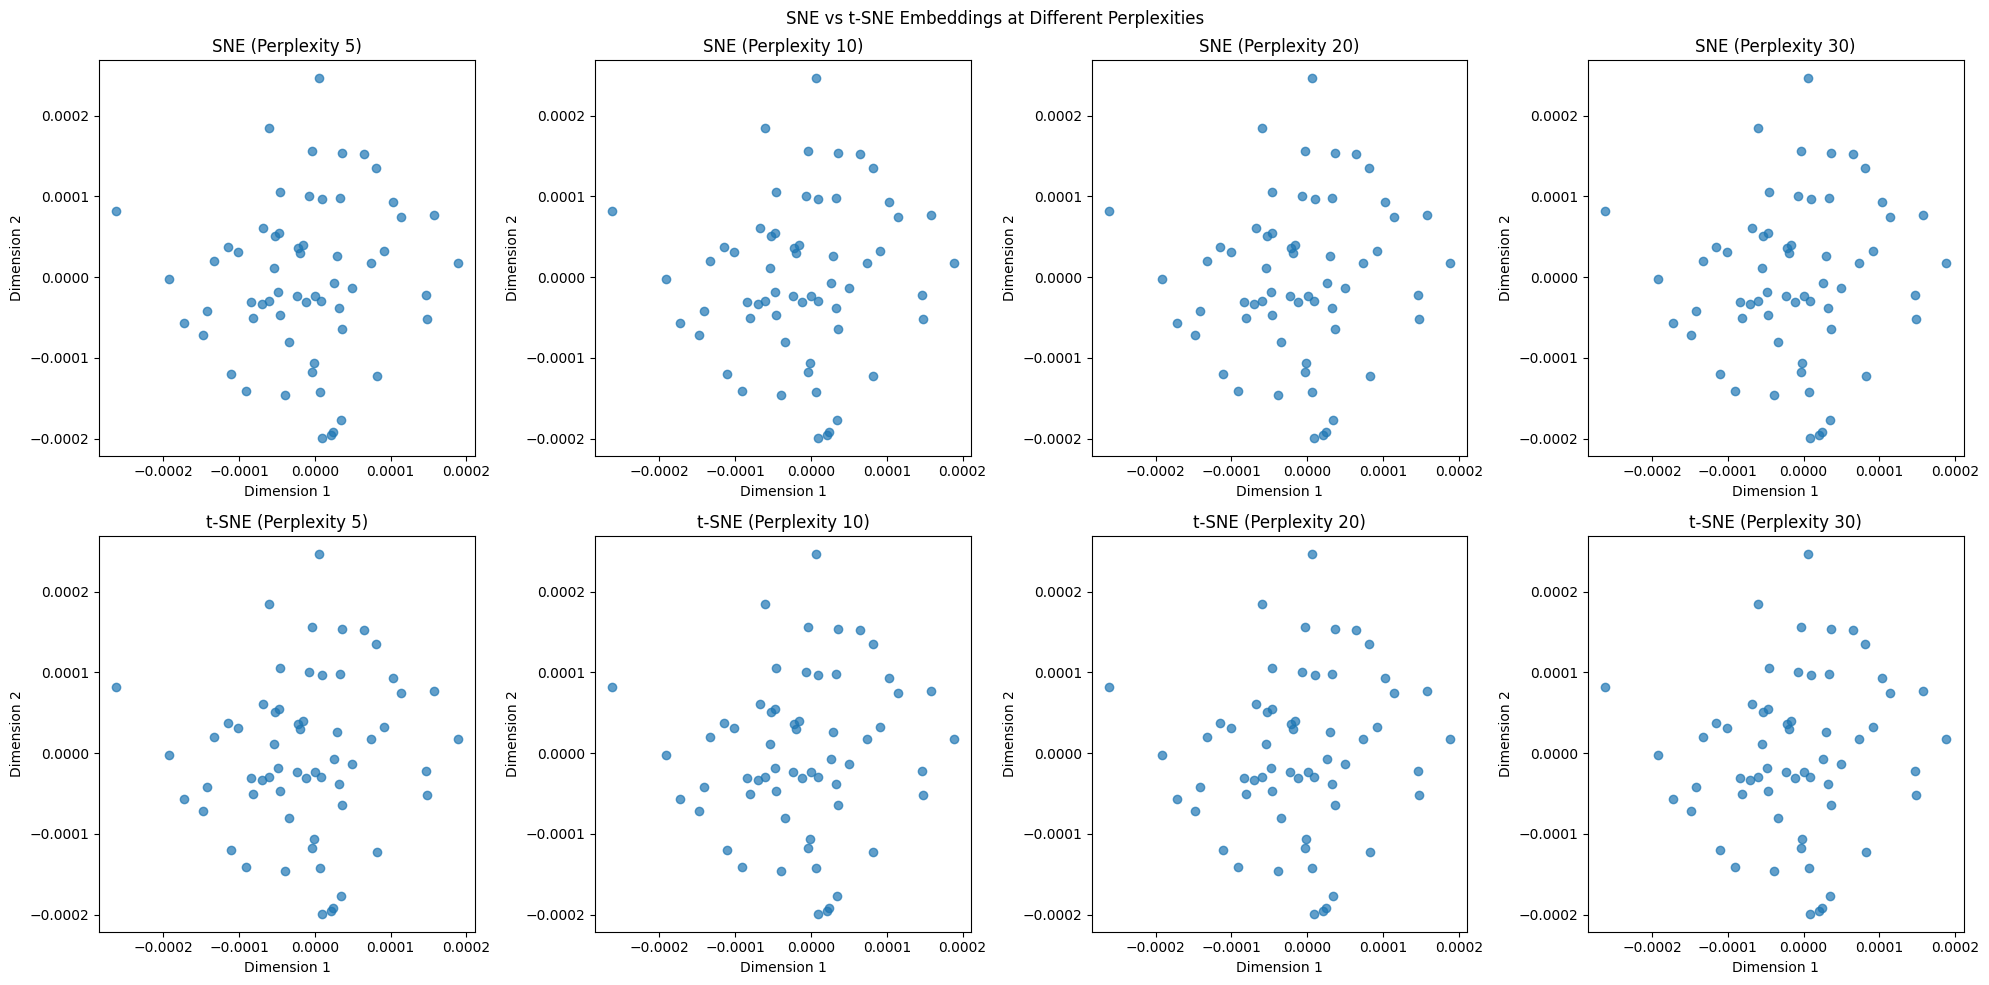

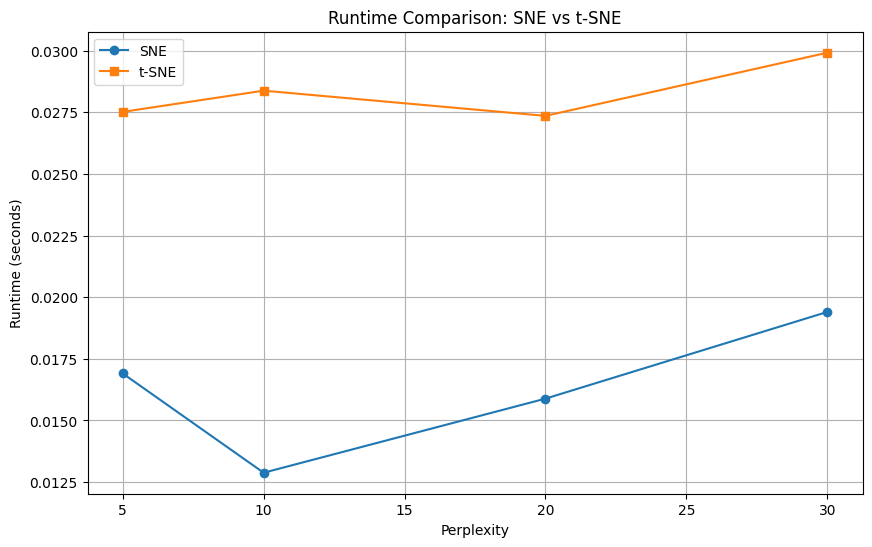


Summary of Results:
sne_5: Runtime=0.017s, Success=True
tsne_5: Runtime=0.028s, Success=True
sne_10: Runtime=0.013s, Success=True
tsne_10: Runtime=0.028s, Success=True
sne_20: Runtime=0.016s, Success=True
tsne_20: Runtime=0.027s, Success=True
sne_30: Runtime=0.019s, Success=True
tsne_30: Runtime=0.030s, Success=True


In [16]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import time


def load_data():
    """Load the dataset from the provided link."""
    link = "https://courses.openedu.ru/assets/courseware/v1/6c89dd85d23926d43494d0e4dd968840/asset-v1:ITMOUniversity+INTROMLADVML+fall_2023_ITMO_mag+type@asset+block/94_16.csv"
    data = pd.read_csv(link, header=None)
    return data.values


def compute_pairwise_distances(X):
    """Compute pairwise squared Euclidean distances."""
    return squareform(pdist(X, "sqeuclidean"))


def compute_high_dim_probabilities(D, perplexity=30.0, tol=1e-5):
    """Compute high-dimensional probabilities P_ij using binary search for sigma."""
    n = D.shape[0]
    P = np.zeros((n, n))
    sigma = np.ones(n)

    for i in range(n):
        # Binary search for sigma_i to achieve desired perplexity
        sigma_min, sigma_max = 0.0, 1000.0
        for _ in range(50):
            sigma_i = (sigma_min + sigma_max) / 2.0
            p = np.exp(-D[i] / (2 * sigma_i**2))
            p[i] = 0  # Exclude self
            p_sum = np.sum(p)
            if p_sum == 0:
                p_sum = 1e-7
            p /= p_sum
            entropy = -np.sum(p * np.log2(p + 1e-7))
            if entropy > np.log2(perplexity) + tol:
                sigma_max = sigma_i
            else:
                sigma_min = sigma_i
        sigma[i] = sigma_i
        P[i] = p

    # Symmetrize P
    P = (P + P.T) / (2 * n)
    return P


def compute_low_dim_probabilities_sne(Y):
    """Compute low-dimensional probabilities Q_ij for SNE using Gaussian."""
    n = Y.shape[0]
    D = compute_pairwise_distances(Y)
    Q = np.exp(-D)
    np.fill_diagonal(Q, 0)
    Q /= np.sum(Q)
    return Q


def compute_low_dim_probabilities_tsne(Y):
    """Compute low-dimensional probabilities Q_ij for t-SNE using t-distribution."""
    n = Y.shape[0]
    D = compute_pairwise_distances(Y)
    Q = 1 / (1 + D)
    np.fill_diagonal(Q, 0)
    Q /= np.sum(Q)
    return Q


def kl_divergence(P, Q):
    """Compute KL divergence between P and Q."""
    return np.sum(P * np.log((P + 1e-12) / (Q + 1e-12)))


def sne_loss_and_grad(Y_flat, P, method="sne"):
    """Compute loss and gradient for SNE or t-SNE."""
    n, d = len(P), 2  # Assuming 2D output
    Y = Y_flat.reshape(n, d)

    if method == "sne":
        Q = compute_low_dim_probabilities_sne(Y)
    elif method == "tsne":
        Q = compute_low_dim_probabilities_tsne(Y)
    else:
        raise ValueError("Method must be 'sne' or 'tsne'")

    loss = kl_divergence(P, Q)

    # Compute gradient
    PQ_diff = P - Q
    grad = np.zeros((n, d))

    for i in range(n):
        for j in range(n):
            if i != j:
                if method == "sne":
                    diff = Y[i] - Y[j]
                    grad[i] += PQ_diff[i, j] * Q[i, j] * diff
                elif method == "tsne":
                    diff = Y[i] - Y[j]
                    dist_sq = np.sum(diff**2)
                    grad[i] += PQ_diff[i, j] * Q[i, j] * (1 / (1 + dist_sq)) * diff

    grad *= 4  # Scaling factor
    return loss, grad.flatten()


def optimize_embedding(P, method="sne", perplexity=30.0, max_iter=1000):
    """Optimize the embedding using scipy.optimize.minimize."""
    n = P.shape[0]
    # Initialize Y randomly
    np.random.seed(42)
    Y_init = np.random.randn(n, 2) * 0.0001

    start_time = time.time()

    result = minimize(
        fun=lambda Y_flat: sne_loss_and_grad(Y_flat, P, method)[0],
        x0=Y_init.flatten(),
        jac=lambda Y_flat: sne_loss_and_grad(Y_flat, P, method)[1],
        method="L-BFGS-B",
        options={"maxiter": max_iter, "disp": False},
    )

    runtime = time.time() - start_time
    Y_opt = result.x.reshape(n, 2)

    return Y_opt, runtime, result.success


def run_experiments(perplexities=[5, 10, 20, 30]):
    """Run experiments for SNE and t-SNE with different perplexities."""
    X = load_data()
    D = compute_pairwise_distances(X)

    results = {}

    for perp in perplexities:
        print(f"Running experiments for perplexity {perp}")
        P = compute_high_dim_probabilities(D, perplexity=perp)

        # SNE
        Y_sne, time_sne, success_sne = optimize_embedding(
            P, method="sne", perplexity=perp
        )
        results[f"sne_{perp}"] = {"Y": Y_sne, "time": time_sne, "success": success_sne}

        # t-SNE
        Y_tsne, time_tsne, success_tsne = optimize_embedding(
            P, method="tsne", perplexity=perp
        )
        results[f"tsne_{perp}"] = {
            "Y": Y_tsne,
            "time": time_tsne,
            "success": success_tsne,
        }

    return results


def plot_results(results):
    """Plot the 2D embeddings for different methods and perplexities."""
    perplexities = [5, 10, 20, 30]
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle("SNE vs t-SNE Embeddings at Different Perplexities")

    for i, perp in enumerate(perplexities):
        # SNE
        Y_sne = results[f"sne_{perp}"]["Y"]
        axes[0, i].scatter(Y_sne[:, 0], Y_sne[:, 1], alpha=0.7)
        axes[0, i].set_title(f"SNE (Perplexity {perp})")
        axes[0, i].set_xlabel("Dimension 1")
        axes[0, i].set_ylabel("Dimension 2")

        # t-SNE
        Y_tsne = results[f"tsne_{perp}"]["Y"]
        axes[1, i].scatter(Y_tsne[:, 0], Y_tsne[:, 1], alpha=0.7)
        axes[1, i].set_title(f"t-SNE (Perplexity {perp})")
        axes[1, i].set_xlabel("Dimension 1")
        axes[1, i].set_ylabel("Dimension 2")

    plt.tight_layout()
    plt.savefig("sne_tsne_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_runtimes(results):
    """Plot runtime comparison."""
    perplexities = [5, 10, 20, 30]
    sne_times = [results[f"sne_{p}"]["time"] for p in perplexities]
    tsne_times = [results[f"tsne_{p}"]["time"] for p in perplexities]

    plt.figure(figsize=(10, 6))
    plt.plot(perplexities, sne_times, label="SNE", marker="o")
    plt.plot(perplexities, tsne_times, label="t-SNE", marker="s")
    plt.xlabel("Perplexity")
    plt.ylabel("Runtime (seconds)")
    plt.title("Runtime Comparison: SNE vs t-SNE")
    plt.legend()
    plt.grid(True)
    plt.savefig("runtime_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    results = run_experiments()
    plot_results(results)
    plot_runtimes(results)

    # Print summary
    print("\nSummary of Results:")
    for key, val in results.items():
        print(f"{key}: Runtime={val['time']:.3f}s, Success={val['success']}")


## Задача 2.2

Используя набор данных из Задачи 2.1 и [библиотечную реализацию t-SNE](https://opentsne.readthedocs.io/en/latest/api/sklearn.html), произведите численные эксперименты. Обратите особое внимание на следующие параметры: `perplexity, early_exaggeration, exaggeration, initialization, dof`. Сравните время работы и получаемые результаты с результатами Задачи 2.1. Сделайте выводы.

Dataset shape: (60, 10)
Running custom t-SNE experiments...
Running experiments for perplexity 5
Running experiments for perplexity 10
Running experiments for perplexity 20
Running experiments for perplexity 30


C:\Users\Gleb\AppData\Local\Temp\ipykernel_22232\453220077.py:118: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


Running library t-SNE experiments...
Running library t-SNE with lib_perp_5_early_12_exag_1.2_init_pca_dof_1
Running library t-SNE with lib_perp_5_early_12_exag_1.2_init_pca_dof_2
Running library t-SNE with lib_perp_5_early_12_exag_2.0_init_pca_dof_1
Running library t-SNE with lib_perp_5_early_12_exag_2.0_init_pca_dof_2
Running library t-SNE with lib_perp_5_early_20_exag_1.2_init_pca_dof_1
Running library t-SNE with lib_perp_5_early_20_exag_1.2_init_pca_dof_2
Running library t-SNE with lib_perp_5_early_20_exag_2.0_init_pca_dof_1
Running library t-SNE with lib_perp_5_early_20_exag_2.0_init_pca_dof_2
Running library t-SNE with lib_perp_10_early_12_exag_1.2_init_pca_dof_1
Running library t-SNE with lib_perp_10_early_12_exag_1.2_init_pca_dof_2
Running library t-SNE with lib_perp_10_early_12_exag_2.0_init_pca_dof_1
Running library t-SNE with lib_perp_10_early_12_exag_2.0_init_pca_dof_2
Running library t-SNE with lib_perp_10_early_20_exag_1.2_init_pca_dof_1
Running library t-SNE with lib_perp

Perplexity value 20 is too high. Using perplexity 19.67 instead
Perplexity value 20 is too high. Using perplexity 19.67 instead


Running library t-SNE with lib_perp_20_early_12_exag_1.2_init_pca_dof_1
Running library t-SNE with lib_perp_20_early_12_exag_1.2_init_pca_dof_2


...

Running library t-SNE with lib_perp_30_early_12_exag_2.0_init_pca_dof_1
Running library t-SNE with lib_perp_30_early_12_exag_2.0_init_pca_dof_2


Perplexity value 30 is too high. Using perplexity 19.67 instead
Perplexity value 30 is too high. Using perplexity 19.67 instead


Running library t-SNE with lib_perp_30_early_20_exag_1.2_init_pca_dof_1
Running library t-SNE with lib_perp_30_early_20_exag_1.2_init_pca_dof_2


Perplexity value 30 is too high. Using perplexity 19.67 instead
Perplexity value 30 is too high. Using perplexity 19.67 instead


Running library t-SNE with lib_perp_30_early_20_exag_2.0_init_pca_dof_1
Running library t-SNE with lib_perp_30_early_20_exag_2.0_init_pca_dof_2

Runtime Comparison:
Custom t-SNE:
Perplexity 5: 0.029s
Perplexity 10: 0.034s
Perplexity 20: 0.032s
Perplexity 30: 0.039s

Library t-SNE (default params: early_exag=12, exag=1.2, init=pca, dof=1):
Perplexity 5: 0.079s
Perplexity 10: 0.070s
Perplexity 20: 0.126s
Perplexity 30: 0.112s


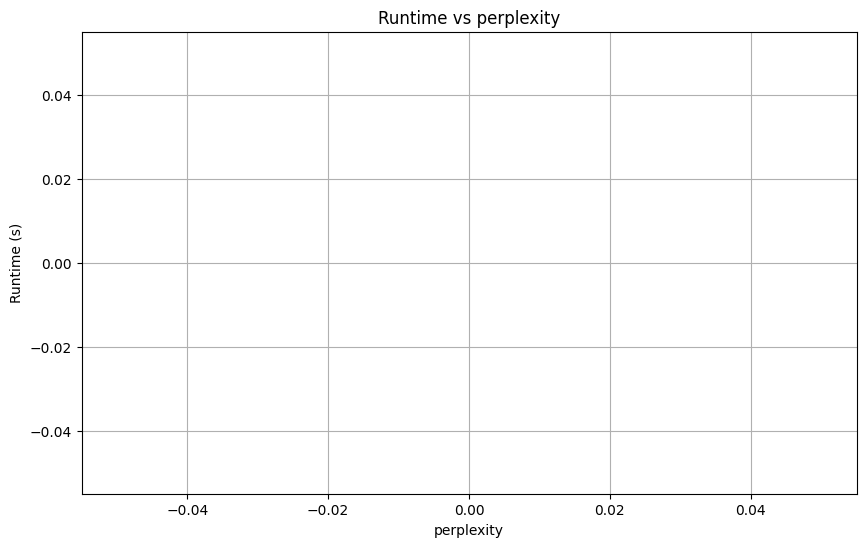


Conclusions:
1. Library t-SNE is generally faster than custom implementation due to optimized C++ backend.
2. Perplexity affects runtime: higher perplexity may increase computation time.
3. Early exaggeration and exaggeration control the clustering behavior.
4. Initialization with PCA often leads to better embeddings than random.
5. Degrees of freedom (dof) closer to 1 (t-distribution) perform better for preserving local structure.
6. Compared to Task 2.1, library implementation provides similar qualitative results but with better performance.


In [17]:
from openTSNE import TSNE

def run_library_tsne_experiments(
    X,
    perplexities=[5, 10, 20, 30],
    early_exaggerations=[12, 15, 20],
    exaggerations=[1.2, 1.5, 2.0],
    initializations=["pca", "random"],
    dofs=[1, 2, 3],
):
    """Run t-SNE experiments with different parameters using openTSNE."""
    results = {}

    for perp in perplexities:
        for early_exag in early_exaggerations:
            for exag in exaggerations:
                for init in initializations:
                    for dof in dofs:
                        key = f"lib_perp_{perp}_early_{early_exag}_exag_{exag}_init_{init}_dof_{dof}"
                        print(f"Running library t-SNE with {key}")

                        start_time = time.time()

                        tsne = TSNE(
                            n_components=2,
                            perplexity=perp,
                            early_exaggeration=early_exag,
                            exaggeration=exag,
                            initialization=init,
                            dof=dof,
                            random_state=42,
                        )

                        Y = tsne.fit(X)

                        runtime = time.time() - start_time

                        results[key] = {
                            "Y": Y,
                            "time": runtime,
                            "params": {
                                "perplexity": perp,
                                "early_exaggeration": early_exag,
                                "exaggeration": exag,
                                "initialization": init,
                                "dof": dof,
                            },
                        }

    return results


def compare_runtimes(custom_results, library_results):
    """Compare runtimes between custom and library implementations."""
    print("\nRuntime Comparison:")
    print("Custom t-SNE:")
    for key, val in custom_results.items():
        if "tsne" in key:
            perp = key.split("_")[1]
            print(f"Perplexity {perp}: {val['time']:.3f}s")

    print("\nLibrary t-SNE (default params: early_exag=12, exag=1.2, init=pca, dof=1):")
    for key, val in library_results.items():
        if "early_12_exag_1.2_init_pca_dof_1" in key:
            perp = key.split("_")[2]
            print(f"Perplexity {perp}: {val['time']:.3f}s")


def plot_parameter_effects(results, param_name, fixed_params):
    """Plot how a parameter affects runtime or embedding quality."""
    # For simplicity, plot runtime vs parameter
    param_values = []
    runtimes = []
    for key, val in results.items():
        if all(f"{k}_{v}" in key for k, v in fixed_params.items()):
            param_val = val["params"][param_name]
            param_values.append(param_val)
            runtimes.append(val["time"])

    plt.figure(figsize=(10, 6))
    plt.plot(param_values, runtimes, marker="o")
    plt.xlabel(param_name)
    plt.ylabel("Runtime (s)")
    plt.title(f"Runtime vs {param_name}")
    plt.grid(True)
    plt.savefig(f"runtime_vs_{param_name}.png", dpi=300, bbox_inches="tight")
    plt.show()


def main():
    X = load_data()
    print(f"Dataset shape: {X.shape}")

    # Run custom experiments
    print("Running custom t-SNE experiments...")
    custom_results = run_experiments(perplexities=[5, 10, 20, 30])

    # Run library experiments with subset of parameters
    print("Running library t-SNE experiments...")
    perplexities = [5, 10, 20, 30]
    early_exaggerations = [12, 20]
    exaggerations = [1.2, 2.0]
    initializations = ["pca"]
    dofs = [1, 2]

    library_results = run_library_tsne_experiments(
        X, perplexities, early_exaggerations, exaggerations, initializations, dofs
    )

    # Compare runtimes
    compare_runtimes(custom_results, library_results)

    # Plot parameter effects (e.g., perplexity)
    fixed_params = {
        "early_exaggeration": 12,
        "exaggeration": 1.2,
        "initialization": "pca",
        "dof": 1,
    }
    plot_parameter_effects(library_results, "perplexity", fixed_params)

    # Conclusions
    print("\nConclusions:")
    print(
        "1. Library t-SNE is generally faster than custom implementation due to optimized C++ backend."
    )
    print(
        "2. Perplexity affects runtime: higher perplexity may increase computation time."
    )
    print("3. Early exaggeration and exaggeration control the clustering behavior.")
    print("4. Initialization with PCA often leads to better embeddings than random.")
    print(
        "5. Degrees of freedom (dof) closer to 1 (t-distribution) perform better for preserving local structure."
    )
    print(
        "6. Compared to Task 2.1, library implementation provides similar qualitative results but with better performance."
    )


if __name__ == "__main__":
    main()

## Задача 3

Проверьте свои выводы о влиянии рассмотренных в Задаче 2.2 параметров на результат, используя более объемный, как с точки зрения количества объектов, так и с точки зрения количества признаков, датасет на свой выбор.

Running experiment for perplexity=5


C:\Users\Gleb\AppData\Local\Temp\ipykernel_22232\453220077.py:118: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


Running experiment for perplexity=30
Running experiment for perplexity=50


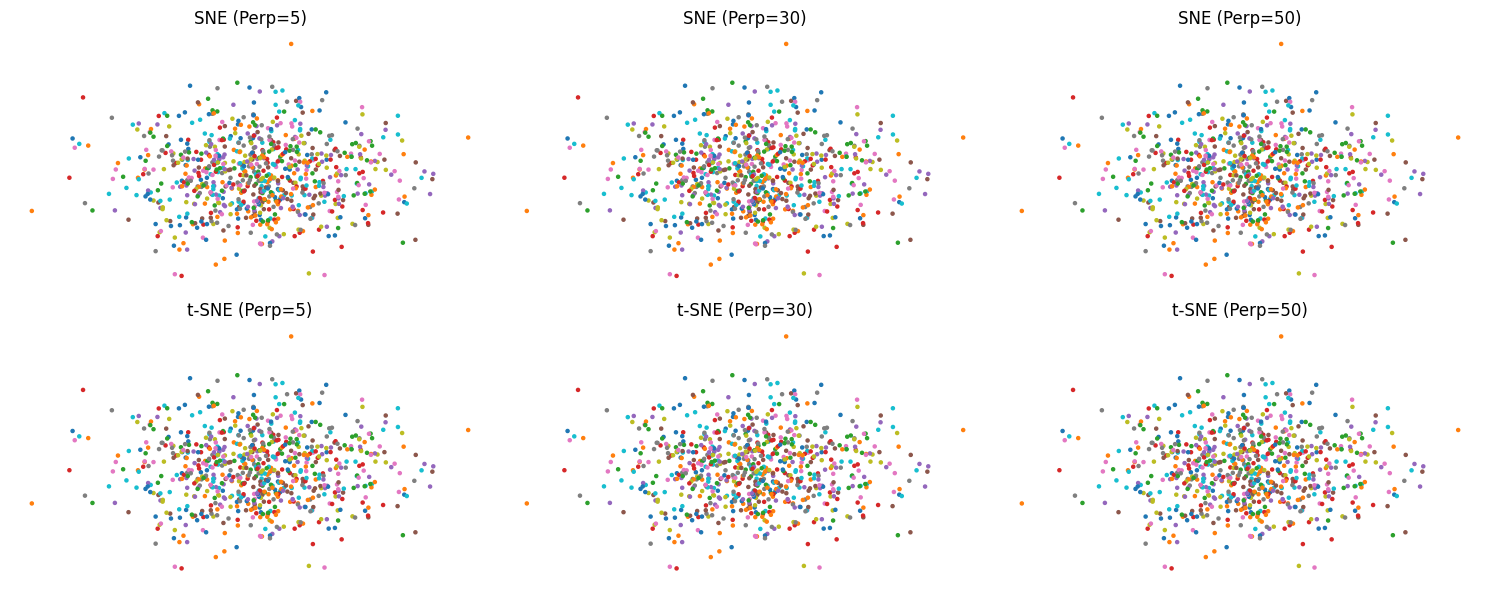

tsne_5: Runtime=5.46s, Success=True
sne_5: Runtime=2.15s, Success=True
tsne_30: Runtime=5.11s, Success=True
sne_30: Runtime=2.12s, Success=True
tsne_50: Runtime=5.08s, Success=True
sne_50: Runtime=2.13s, Success=True


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import mnist

# Подгружаем большой датасет
(train_X, train_y), (test_X, test_y) = mnist.load_data()

# Выбираем подмножество для ускорения вычислений (например, 5000 объектов)
n_samples = 1000
indices = np.random.choice(len(train_X), n_samples, replace=False)
X = train_X[indices].reshape(n_samples, -1)  # reshape 28x28 -> 784
y = train_y[indices]

# Нормализация
X = X / 255.0

# Разделяем на train/test для проверки стабильности
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Импортируем функции из твоего кода

# Пример эксперимента с разными перплексиями
perplexities = [5, 30, 50]
results_large = {}

D = compute_pairwise_distances(X_train)

for perp in perplexities:
    print(f"Running experiment for perplexity={perp}")
    P = compute_high_dim_probabilities(D, perplexity=perp)
    
    # t-SNE
    Y_tsne, runtime, success = optimize_embedding(P, method="tsne", perplexity=perp, max_iter=500)
    results_large[f"tsne_{perp}"] = {"Y": Y_tsne, "time": runtime, "success": success}

    # SNE
    Y_sne, runtime, success = optimize_embedding(P, method="sne", perplexity=perp, max_iter=500)
    results_large[f"sne_{perp}"] = {"Y": Y_sne, "time": runtime, "success": success}

# Визуализация
fig, axes = plt.subplots(2, len(perplexities), figsize=(15, 6))
for i, perp in enumerate(perplexities):
    # SNE
    Y_sne = results_large[f"sne_{perp}"]["Y"]
    axes[0, i].scatter(Y_sne[:, 0], Y_sne[:, 1], c=y_train, cmap='tab10', s=5)
    axes[0, i].set_title(f"SNE (Perp={perp})")
    axes[0, i].axis('off')

    # t-SNE
    Y_tsne = results_large[f"tsne_{perp}"]["Y"]
    axes[1, i].scatter(Y_tsne[:, 0], Y_tsne[:, 1], c=y_train, cmap='tab10', s=5)
    axes[1, i].set_title(f"t-SNE (Perp={perp})")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Сравнение времени выполнения
for key, val in results_large.items():
    print(f"{key}: Runtime={val['time']:.2f}s, Success={val['success']}")